# Feature Engineering I

**Manual Feature Engineering: Daily Return, Historical Volatility**

Author: Pete King

This notebook computes additional financial features for all sector ETFs and selected market indicies.  Specifically we compute daily returns and near-term historical volatility for each asset/index.  We also calculate the training labels for ETFs: a return and volatility forecast over a near-term outlook.


In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import numpy as np
import pandas as pd

import data_prep as dp

ETF_DATA_FILE = 'etf_raw_data.csv'
INDICIES_DATA_FILE = 'filled_indicies_data.csv'

WINDOW_SIZE = 10  # No. business days for historical volatility feature
OUTLOOK = 21  # Future outlook (no. business days) for future volatility label

## I. Import data

In [2]:
etf_df = pd.read_csv(
    ETF_DATA_FILE,
    index_col='date',
    parse_dates=True
)
indicies_df = pd.read_csv(
    INDICIES_DATA_FILE,
    index_col='date',
    parse_dates=True
)

We want to compute return and volatility labels for all ETFs and selected indicies.  The volatility indexes (VIX, VXN, and MOVE) are not price indexes and will be most useful without any transformation.  Each represents a roughly 30 calendar day forecast for volatility -- which is what we are trying to forecast ourselves.  Each volatility index thus effectively provides the forecast output of a complex economic model that our own models can take advantage of.

In [3]:
tickers = etf_df.columns
# From Tom's notebook:  We want to compute return and volatility for these
indicies = [
    # Treasury bond index
    'SHY',
    # Commodity futures
    'CL=F', 'GC=F', 'HG=F', 'NG=F',
    # Equity indicies
    '^FTSE', '^GSPC', '^HSI',
]
# Note that we place volatility indicies (^VIX, ^VXN, ^MOVE) in a separate list
vol_indicies = ['^VIX', '^VXN', '^MOVE']

## II. Compute Features and Labels for ETFs

### Daily return (feature) and future return (label)

Return represents a change in the price of an asset.  Daily return is given by the formula:

*return_t = log(price_t / price_t-1)*

While the future return forecast (in business days) will be computed as:

*return_target_t = log(price_t+OUTLOOK / price_t)*


In [4]:
etf_ret, etf_ret_h, etf_ret_f = {}, {}, {}
for ticker in tickers:
    # Compute daily return (feature)
    etf_ret[ticker + '_ret'] = (
        np.log(etf_df[ticker].values / etf_df[ticker].shift(1).values)
    )
    # Compute near term (1-2 week) historical return (feature)
    etf_ret_h[ticker + '_ret-h'] = (
        np.log(etf_df[ticker].values / etf_df[ticker].shift(WINDOW_SIZE).values)
    )
    # Compute future monthly return (label)
    etf_ret_f[ticker + '_ret-target'] = (
        np.log(etf_df[ticker].shift(-OUTLOOK).values / etf_df[ticker].values)
    )
pd.DataFrame(etf_ret, index=etf_df.index)

,BIL_ret,BND_ret,GLD_ret,HYG_ret,IEF_ret,IWM_ret,LQD_ret,QQQ_ret,SPY_ret,TIP_ret,...,XLB_ret,XLE_ret,XLF_ret,XLI_ret,XLK_ret,XLP_ret,XLRE_ret,XLU_ret,XLV_ret,XLY_ret
date,,,,,,,,,,,,,,,,,,,,,
1993-01-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007088,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002116,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010516,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004175,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-20,0.000328,-0.008031,-0.031034,-0.009333,-0.009023,-0.022089,-0.012348,-0.018655,-0.014440,-0.008042,...,-0.016048,-0.000843,0.001835,-0.014675,-0.022944,-0.008330,-0.032241,-0.041458,-0.008769,-0.018028
2026-03-23,0.000109,0.003819,-0.022853,0.006567,0.003157,0.021362,0.006562,0.010153,0.010445,-0.000272,...,0.012060,0.005381,0.003864,0.008500,0.012195,-0.001354,0.000739,0.002907,-0.003861,0.021850
2026-03-24,0.000109,-0.002590,0.000223,-0.003405,-0.003368,0.005360,-0.002029,-0.006860,-0.003362,-0.003272,...,0.018751,0.020089,0.000203,0.005810,-0.005859,-0.000863,-0.008157,0.006899,0.000138,-0.004004


### Historical volatility (feature) and future volatility (label)

Volatility measures variability in an asset's price and is estimated in practice using a sample of the asset's periodic returns.  If we think of return for an asset as a random variable **R**, then the asset's historical volatility over a period of time is simply the *standard deviation* of its returns over that period.

Since we don't know all possible values that the random variable **R** might take in the future, we will never know it's true properties (i.e., *population* mean and variance).  But we can compute estimates of those properties using historical data.  Typically, the formulas for average return and historical volatility over a period of time are given as:

*Average_Return (R_bar) = sum(R_i) / n, for i=1, 2, ..., n  (i.e., sample mean)*

*Historical_Volatility (sigma) = sqrt(sum( (R_i - R_bar)^2 ) / (n - 1) )), for i=1, 2, ..., n (i.e., sample standard deviation)*

One important assumption that we use in our calculations is the "zero mean" assumption for return, which simply states that the expected value (i.e., population mean) of any asset's return is zero, i.e., E\[**R**\] = 0.  As we saw in our earlier inspection of return data for the SPY, the average long-term return over all historical data was very close to zero -- empirical evidence that the zero mean assumption for returns is valid.

The zero mean assumption is especially useful when dealing with a small sample of returns, as we do here with our rolling windows (10-21 business days).  Consider a run of 10 business days where daily returns were consistently positive.  The average daily return for that small set of 10 business days would also be positive and would be much closer to each day's daily return value than the long-term historical average return (R_bar).  Therefore, the zero-mean assumption serves to improve our measure of variability in a sample compared to the *long-term* average return.

Using the zero-mean assumption for returns, we compute volatility for a sample of returns as:

*volatility = sqrt(sum(R_i^2) / n), for i=1, 2, ..., n*

where *n* is the number of business days in the sample.  We do not use Bessel's correction here (i.e., divide by (n - 1)) because we do not lose a degree of freedom from estimating the sample average (R_bar).

We decided to use *n = 10* for a computation of the historical volatility feature, with *n = 21* for the future volatility label.  Several factors informed these decisions:
 1. Literature shows that the past 5 days of volatility are highly correlated with future volatility.  Auto-correlation of daily returns tends to decline rapidly after lag increases beyond 5-10 days.
 2. A 5-day sample of returns would be a very small sample and would likely over-represent volatility, as volatility essentially measures the variance in returns.  In general, smaller samples tend to have higher variance, so our historical volatility feature might overrepresent the true variance in daily returns.
 4. A future outlook of 21 business days aligns with the 30 calendar day outlook of the VIX, VXN, and MOVE forecasts for volatility.
 5. Much like the weather, accurately forecasting market behavior beyond 2-4 weeks is problematic.  We saw this in the literature and throughout the course of our own analysis here.

In [5]:
# Make volatility features & targets using daily return data
etf_vol_h, etf_vol_f = {}, {}
for ticker in tickers:
    etf_return = pd.Series(etf_ret[ticker + '_ret'], index=etf_df.index)
    # Compute historical volatility (feature)
    etf_vol_h[ticker + '_vol-h'] = (
    etf_return.rolling(WINDOW_SIZE).apply(dp.volatility, raw=True).values
    )
    # Compute future volatility (label)
    etf_vol_f[ticker + '_vol-target'] = (
        etf_return.shift(-OUTLOOK).rolling(OUTLOOK).apply(
            dp.volatility, raw=True
        ).values
    )

In [6]:
# Combine engineered features into final ETF DataFrame
etf_df = pd.concat(
    [
        pd.DataFrame(etf_ret, index=etf_df.index),
        pd.DataFrame(etf_ret_h, index=etf_df.index),
        pd.DataFrame(etf_vol_h, index=etf_df.index),
        pd.DataFrame(etf_ret_f, index=etf_df.index),
        pd.DataFrame(etf_vol_f, index=etf_df.index)
    ], axis=1
)
etf_df

,BIL_ret,BND_ret,GLD_ret,HYG_ret,IEF_ret,IWM_ret,LQD_ret,QQQ_ret,SPY_ret,TIP_ret,...,XLB_vol-target,XLE_vol-target,XLF_vol-target,XLI_vol-target,XLK_vol-target,XLP_vol-target,XLRE_vol-target,XLU_vol-target,XLV_vol-target,XLY_vol-target
date,,,,,,,,,,,,,,,,,,,,,
1993-01-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007088,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002116,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010516,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004175,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-20,0.000328,-0.008031,-0.031034,-0.009333,-0.009023,-0.022089,-0.012348,-0.018655,-0.014440,-0.008042,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-23,0.000109,0.003819,-0.022853,0.006567,0.003157,0.021362,0.006562,0.010153,0.010445,-0.000272,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-24,0.000109,-0.002590,0.000223,-0.003405,-0.003368,0.005360,-0.002029,-0.006860,-0.003362,-0.003272,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


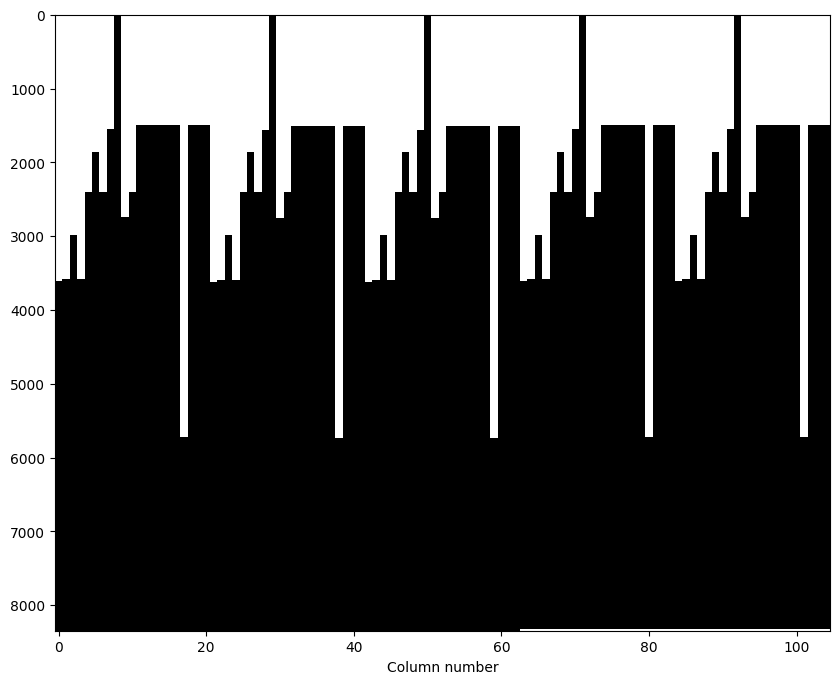

In [7]:
dp.view_nan(etf_df);

In [8]:
etf_df.to_csv('etf_transformed.csv', index_label='date')

## III. Compute features for selected indicies

### Return and volatility

We repeat the process of computing daily return and near-term historical volatility for selected indicies.


In [9]:
# Compute daily return and near-term return
ind_ret, ind_ret_h = {}, {}
for index in indicies:
    # Compute daily return (feature)
    ind_ret[index + '_ret'] = (
        np.log(indicies_df[index].dropna().values
               / indicies_df[index].dropna().shift(1).values
              )
    )
    # Compute near-term (1-2 week) historical return (feature)
    ind_ret_h[index + '_ret-h'] = (
        np.log(indicies_df[index].dropna().values
               / indicies_df[index].dropna().shift(WINDOW_SIZE).values
              )
    )
pd.DataFrame(ind_ret, index=indicies_df.index)

,SHY_ret,CL=F_ret,GC=F_ret,HG=F_ret,NG=F_ret,^FTSE_ret,^GSPC_ret,^HSI_ret
date,,,,,,,,
2002-11-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-11-13,0.000122,-0.027796,-0.018035,-0.004880,0.001291,-0.013729,-0.000476,0.000289
2002-11-14,-0.002442,0.003962,-0.002513,-0.007013,-0.002066,0.005865,0.024335,0.012834
2002-11-15,0.000489,0.008661,0.008769,0.009107,0.028537,0.009454,0.006130,0.012732
2002-11-18,0.000000,0.045967,-0.004688,0.013851,0.068440,0.005946,-0.010463,0.005503
...,...,...,...,...,...,...,...,...
2026-03-20,-0.002184,0.022422,-0.006608,-0.016798,-0.022681,-0.014534,-0.015254,-0.008794
2026-03-23,0.001457,-0.109414,-0.037065,0.017993,-0.068185,-0.002433,0.011388,-0.036043
2026-03-24,-0.001457,0.046773,-0.001091,-0.003130,0.017827,0.007150,-0.003750,0.027557


In [10]:
# Compute near-term historical volatility
ind_vol_h = {}
for index in indicies:
    ind_return = pd.Series(ind_ret[index + '_ret'], index=indicies_df.index)
    # Compute historical volatility (feature)
    ind_vol_h[index + '_vol-h'] = (
    ind_return.rolling(WINDOW_SIZE).apply(dp.volatility, raw=True).values
    )
pd.DataFrame(ind_vol_h, index=indicies_df.index)

,SHY_vol-h,CL=F_vol-h,GC=F_vol-h,HG=F_vol-h,NG=F_vol-h,^FTSE_vol-h,^GSPC_vol-h,^HSI_vol-h
date,,,,,,,,
2002-11-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-11-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-11-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-11-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-11-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2026-03-20,0.001199,0.058060,0.023734,0.016870,0.030309,0.011384,0.009391,0.012392
2026-03-23,0.001276,0.066289,0.026254,0.017644,0.036602,0.011358,0.009712,0.016275
2026-03-24,0.001343,0.054726,0.024853,0.016763,0.035572,0.010455,0.009760,0.017167


### First difference for Treasury Yield

Follow Tom's guidance for transforming Treasury yield using a first difference (i.e., "delta") from one observation to the next.

In [11]:
t_yield = {
    '^TNX_diff': indicies_df['^TNX'].diff()
}

Now we combine all transformed indicies and save to a CSV file for later use.

In [12]:
indicies_df = pd.concat(
    [
        indicies_df[vol_indicies].copy(),
        pd.DataFrame(ind_ret, index=indicies_df.index),
        pd.DataFrame(ind_vol_h, index=indicies_df.index),
        pd.DataFrame(t_yield, index=indicies_df.index)
    ], axis=1
)
indicies_df

,^VIX,^VXN,^MOVE,SHY_ret,CL=F_ret,GC=F_ret,HG=F_ret,NG=F_ret,^FTSE_ret,^GSPC_ret,^HSI_ret,SHY_vol-h,CL=F_vol-h,GC=F_vol-h,HG=F_vol-h,NG=F_vol-h,^FTSE_vol-h,^GSPC_vol-h,^HSI_vol-h,^TNX_diff
date,,,,,,,,,,,,,,,,,,,,
2002-11-12,30.580000,55.250000,120.209999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-11-13,31.240000,54.459999,122.879997,0.000122,-0.027796,-0.018035,-0.004880,0.001291,-0.013729,-0.000476,0.000289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.013
2002-11-14,28.670000,52.400002,130.289993,-0.002442,0.003962,-0.002513,-0.007013,-0.002066,0.005865,0.024335,0.012834,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.183
2002-11-15,26.650000,49.680000,132.350006,0.000489,0.008661,0.008769,0.009107,0.028537,0.009454,0.006130,0.012732,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.030
2002-11-18,27.660000,48.090000,129.139999,0.000000,0.045967,-0.004688,0.013851,0.068440,0.005946,-0.010463,0.005503,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-20,26.780001,29.200001,108.839996,-0.002184,0.022422,-0.006608,-0.016798,-0.022681,-0.014534,-0.015254,-0.008794,0.001199,0.058060,0.023734,0.016870,0.030309,0.011384,0.009391,0.012392,0.110
2026-03-23,26.150000,27.980000,98.150002,0.001457,-0.109414,-0.037065,0.017993,-0.068185,-0.002433,0.011388,-0.036043,0.001276,0.066289,0.026254,0.017644,0.036602,0.011358,0.009712,0.016275,-0.057
2026-03-24,26.950001,28.740000,103.010002,-0.001457,0.046773,-0.001091,-0.003130,0.017827,0.007150,-0.003750,0.027557,0.001343,0.054726,0.024853,0.016763,0.035572,0.010455,0.009760,0.017167,0.058


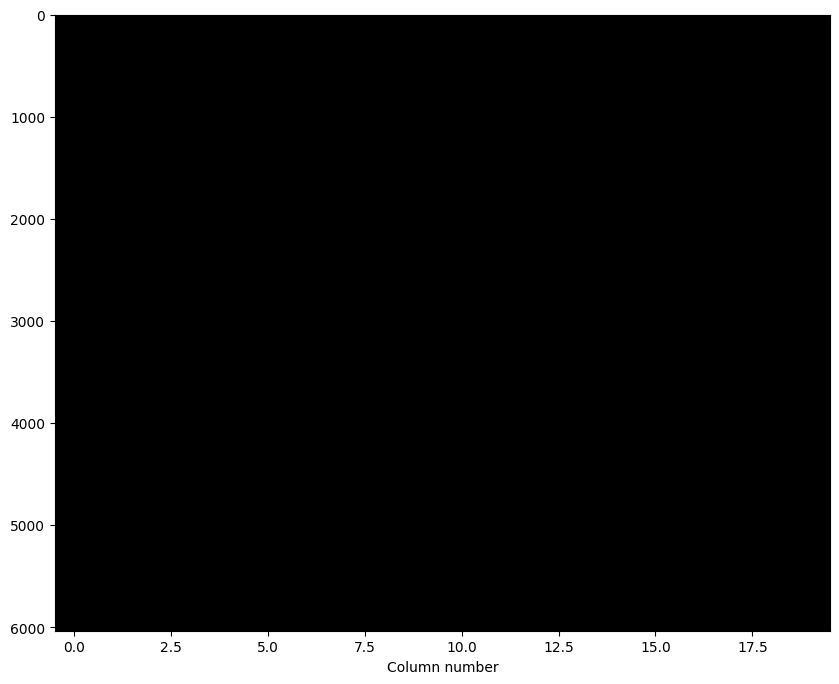

In [13]:
dp.view_nan(indicies_df);

In [14]:
indicies_df.to_csv('indicies_transformed.csv', index_label='date')